In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [2]:
import pandas as pd
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder


df = pd.read_csv('C:/Users/Lenovo/OneDrive/Desktop/BinX training/Project/data/heart_disease_clean.csv')


#  Prepare the data
X = df.drop(columns=['Result'])   
y = df['Result']

le = LabelEncoder()
y = le.fit_transform(y)   # encode positive -> 1, negative -> 0 

# Split into train / validation / test
X_train_full, X_test, y_train_full, y_test = train_test_split( X, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full)

# Scale AFTER splitting (fit only on train, to avoid data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

n_features = X_train.shape[1]

# --- Build the model ---
model = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid"),   # binary output
])

model.summary()

c:\Users\Lenovo\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# compile and train
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6411 - loss: 0.6441 - val_accuracy: 0.6726 - val_loss: 0.6270
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6832 - loss: 0.5985 - val_accuracy: 0.7262 - val_loss: 0.5909
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7105 - loss: 0.5706 - val_accuracy: 0.7381 - val_loss: 0.5635
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7158 - loss: 0.5494 - val_accuracy: 0.7381 - val_loss: 0.5442
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7316 - loss: 0.5327 - val_accuracy: 0.7440 - val_loss: 0.5221
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7505 - loss: 0.5167 - val_accuracy: 0.7440 - val_loss: 0.5080
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7568 - loss: 0.5015 - val_accuracy: 0.7619 - val_loss: 0.5014
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7642 - loss: 0.4911 - val_accuracy: 0.7798 - val_loss

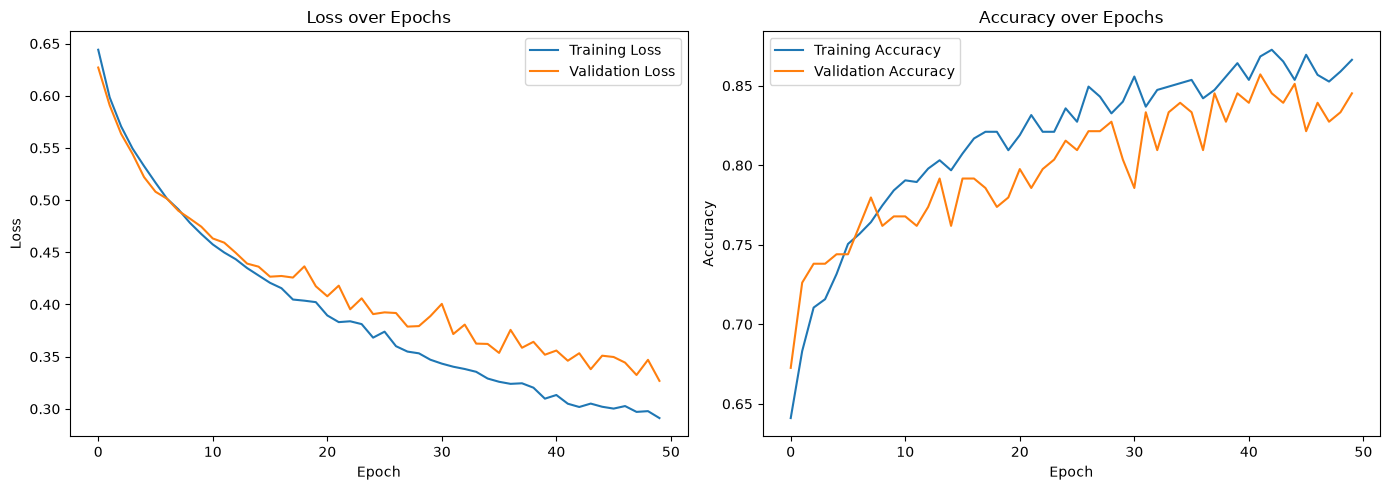

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy curve
axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [5]:
from tensorflow.keras.layers import BatchNormalization, Dropout

model_v2 = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

model_v2.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_v2 = model_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5547 - loss: 0.8150 - val_accuracy: 0.6250 - val_loss: 0.6600
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5916 - loss: 0.7325 - val_accuracy: 0.6429 - val_loss: 0.6347
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6274 - loss: 0.6683 - val_accuracy: 0.6607 - val_loss: 0.6156
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6358 - loss: 0.6571 - val_accuracy: 0.6667 - val_loss: 0.6073
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6337 - loss: 0.6340 - val_accuracy: 0.6667 - val_loss: 0.5917
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6621 - loss: 0.6186 - val_accuracy: 0.6905 - val_loss: 0.5800
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6653 - loss: 0.6098 - val_accuracy: 0.7024 - val_loss: 0.5611
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6832 - loss: 0.5878 - val_accuracy: 0.7262 - val_loss

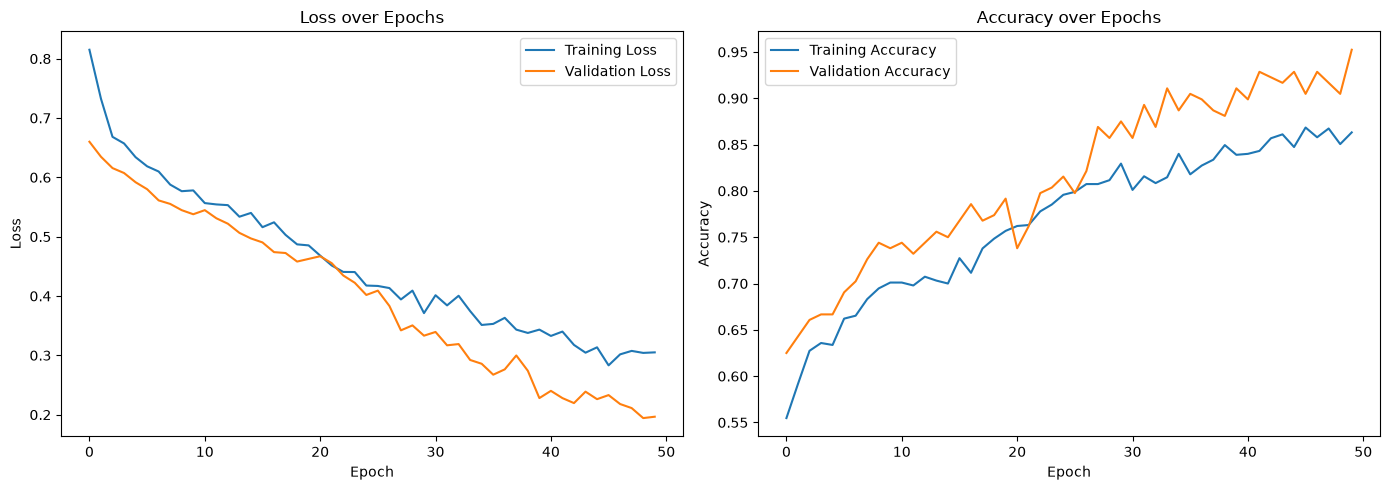

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history_v2.history['loss'], label='Training Loss')
axes[0].plot(history_v2.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy curve
axes[1].plot(history_v2.history['accuracy'], label='Training Accuracy')
axes[1].plot(history_v2.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
print("Model v1 (no Dropout/BatchNorm):")
model.evaluate(X_test, y_test)

print("\nModel v2 (with Dropout/BatchNorm):")
model_v2.evaluate(X_test, y_test)

Model v1 (no Dropout/BatchNorm):
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7929 - loss: 0.3809 

Model v2 (with Dropout/BatchNorm):
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8889 - loss: 0.2460 


[0.24596410989761353, 0.8888888955116272]

## Summary — Neural Networks with Keras

Built a Keras `Sequential` model (Dense layers, sigmoid output) for binary classification on the medical dataset.

**Workflow:** `compile()` → `fit()` with validation split → `evaluate()` on test set.

**Diagnosis:** Plotting `history` showed a healthy fit — training/validation loss and accuracy tracked closely, with only a mild early overfitting signal.

**Dropout + BatchNormalization:** Added both layers. Validation metrics looked better than training during `fit()` — expected, since Dropout is active in training but off during evaluation, making that comparison unfair. The real comparison is `evaluate()`, where Dropout is off for both.

**Results (test set):**

| Model | Accuracy |
|---|---|
| Logistic Regression (baseline) | 0.792 |
| NN v1 (no regularization) | 0.793 |
| NN v2 (Dropout + BatchNorm) | **0.889** |

**Takeaway:** A plain NN didn't beat the classical baseline on this small dataset — regularization (Dropout + BatchNorm), not depth, drove the real improvement.